## Section 1: Setup & Data Loading

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
from itertools import combinations

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [105]:
df_raw = pd.read_csv("pa2_data.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.shape[1]}")
df_raw.head()

Raw data shape: (80387, 220)
Columns: 220


,ID,PATID,UCX_abnormal,ua_bacteria,ua_bili,ua_blood,ua_clarity,ua_color,ua_epi,ua_glucose,...,SKIN_PREPS,SMOKING_DETERRENTS,THYROID_PREPS,UNCLASSIFIED_DRUG_PRODUCTS,VITAMINS,dispo,UTI_diag,split,abxUTI,alt_diag
0,1,1,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,No,No,No,Admit,Yes,training,yes,0
1,2,1,no,many,negative,small,clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
2,3,2,yes,few,negative,negative,clear,yellow,small,negative,...,No,No,Yes,Yes,No,Discharge,No,training,no,0
3,4,3,yes,many,negative,negative,not_clear,yellow,not_reported,negative,...,No,No,No,No,Yes,Admit,Yes,training,yes,0
4,5,4,no,moderate,small,negative,clear,orange,not_reported,negative,...,No,No,No,No,No,AMA,No,training,no,0


---
## Section 2: Target Variable & Alternative Labels (Short Answer 1)

In [106]:
target_col = "UCX_abnormal"
alternative_labels = ["UTI_diag", "abxUTI", "alt_diag"]

print("Target variable distribution")
print(df_raw[target_col].value_counts())
print()

print("Alternative labels (to be removed)")
for col in alternative_labels:
    if col in df_raw.columns:
        print(f"{col}: {df_raw[col].value_counts().to_dict()}")

Target variable distribution
UCX_abnormal
no     62103
yes    18284
Name: count, dtype: int64

Alternative labels (to be removed)
UTI_diag: {'No': 63221, 'Yes': 17166}
abxUTI: {'yes': 45151, 'no': 35236}
alt_diag: {0: 75883, 1: 4504}


In [107]:
# Encode target: yes=1, no=0
df_raw[target_col] = df_raw[target_col].map({"yes": 1, "no": 0})

print("Target after encoding:")
print(df_raw[target_col].value_counts())

Target after encoding:
UCX_abnormal
0    62103
1    18284
Name: count, dtype: int64


**Short Answer 1:**  
The target variable selected is `UCX_abnormal`, which represents a positive urine culture result. The alternative labels identified and removed from the dataset are:  `UTI_diag`,`abxUTI` , `alt_diag`. These were removed because they represent alternative outcome definitions that could introduce data leakage if used as features.

---
## Section 3: EDA — Table 1 (Cohort Demographics)

In [108]:
# Demographics columns for Table 1
demo_cols = ["age", "gender", "race", "ethnicity", "chief_complaint"]

In [109]:
from tableone import TableOne
# Separate continuous and categorical columns for tableone
categorical_demo = [c for c in demo_cols if df_raw[c].dtype == 'object' and c in df_raw.columns]
table1 = TableOne(
    df_raw,
    columns=demo_cols,
    categorical=categorical_demo,
    groupby=target_col,
    pval=False,
    missing=False,
    label_suffix=False
)
table1

Grouped by UCX_abnormal                            
                                                                          Overall             0             1
n                                                                           80387         62103         18284
age                                                                   53.8 (22.3)   52.7 (21.7)   57.6 (23.6)
gender          Female                                               54725 (68.1)  40390 (65.0)  14335 (78.4)
                Male                                                 24584 (30.6)  20829 (33.5)   3755 (20.5)
                not_reported                                           1078 (1.3)     884 (1.4)     194 (1.1)
race            American Indian or Alaska Native                         94 (0.1)      81 (0.1)      13 (0.1)
                Asian                                                   860 (1.1)     680 (1.1)     180 (1.0)
                Black or African American                            17003 (21.2)  13289 (21.4)   3714 (20.3)
                Hispanic/Latino                                        1667 (2.1)    1178 (1.9)     489 (2.7)
                Native Hawaiian or Other Pacific Islander                45 (0.1)      39 (0.1)       6 (0.0)
                Other                                                14929 (18.6)  11597 (18.7)   3332 (18.2)
                Patient Refused                                         967 (1.2)     782 (1.3)     185 (1.0)
                Unknown                                                 587 (0.7)     465 (0.7)     122 (0.7)
                White or Caucasian                                   43156 (53.7)  33108 (53.3)  10048 (55.0)
                not_reported                                           1079 (1.3)     884 (1.4)     195 (1.1)
ethnicity       Hispanic or Latino                                   17064 (21.2)  13090 (21.1)   3974 (21.7)
                Non-Hispanic                                         61826 (76.9)  47807 (77.0)  14019 (76.7)
                Patient Refused                                         142 (0.2)     114 (0.2)      28 (0.2)
                Unknown                                                 277 (0.3)     208 (0.3)      69 (0.4)
                not_reported                                           1078 (1.3)     884 (1.4)     194 (1.1)
chief_complaint ABDOMINAL PAIN                                       23626 (29.4)  19335 (31.1)   4291 (23.5)
                ALTERED MENTAL STATUS                                  4822 (6.0)    3445 (5.5)    1377 (7.5)
                BACK PAIN                                              1658 (2.1)    1309 (2.1)     349 (1.9)
                CHEST PAIN                                             1806 (2.2)    1486 (2.4)     320 (1.8)
                DIZZINESS                                              1417 (1.8)    1166 (1.9)     251 (1.4)
                DYSURIA                                                1093 (1.4)     641 (1.0)     452 (2.5)
                EMESIS                                                 2963 (3.7)    2188 (3.5)     775 (4.2)
                FALL                                                   1021 (1.3)     787 (1.3)     234 (1.3)
                FATIGUE                                                1654 (2.1)    1309 (2.1)     345 (1.9)
                FEMALE GU PROBLEM                                      1874 (2.3)    1088 (1.8)     786 (4.3)
                FEVER                                                  1397 (1.7)    1154 (1.9)     243 (1.3)
                FEVER-9 WEEKS TO 74 YEARS                              2023 (2.5)    1364 (2.2)     659 (3.6)
                FLANK PAIN                                             6300 (7.8)    5040 (8.1)    1260 (6.9)
                HEMATURIA                                              1293 (1.6)     889 (1.4)     404 (2.2)
                MALE GU PROBLEM                                        1675 (2.1)    1250 (2.0)   

---
## Section 4: Data Preprocessing

In [110]:
# Save dev/val split masks BEFORE dropping split column
dev_set = (df_raw['split'] == 'training').values
val_set  = (df_raw['split'] == 'validation').values
print(f"Dev (training rows):   {dev_set.sum()}")
print(f"Val (validation rows): {val_set.sum()}")

# ── Predictor variables (from S3 supplementary table) ──
PREDICTOR_COLS = [
    # Urinalysis
    "ua_bacteria", "ua_bili", "ua_blood", "ua_clarity", "ua_color",
    "ua_epi", "ua_glucose", "ua_ketones", "ua_leuk", "ua_nitrite",
    "ua_ph", "ua_protein", "ua_rbc", "ua_spec_grav", "ua_urobili", "ua_wbc",
    # Physical Findings
    "CVA_tenderness", "abd_tenderness", "abd_soft", "abd_distended",
    "abd_gaurding", "abd_mass", "abd_rebound", "abd_rigidity",
    "back_pain", "fatigue", "fever", "vag_bleeding", "vag_discharge",
    "abd_distended2", "abd_pain", "gen_neg", "pelvic_pain",
    "alert", "ams", "weakness", "oriented", "psychiatric_confusion",
    "flank_pain", "dec_urine_vol", "diff_urinating", "dysuria",
    "hematuria", "polyuria",
    # Demographics / Arrival Info
    "chief_complaint", "age", "gender", "race", "ethnicity",
    "lang", "maritalStatus", "employStatus", "insurance_status", "arrival",
    # Vitals
    "Temp_First", "Temp_Last", "Temp_Max", "Temp_Min", "Temp_Mean",
    "HR_First", "HR_Last", "HR_Max", "HR_Min", "HR_Mean",
    "SBP_First", "SBP_Last", "SBP_Max", "SBP_Min", "SBP_Mean",
    "DBP_First", "DBP_Last", "DBP_Max", "DBP_Min", "DBP_Mean",
    "RR_First", "RR_Last", "RR_Max", "RR_Min", "RR_Mean",
    "O2_Sat_First", "O2_Sat_Last", "O2_Sat_Max", "O2_Sat_Min", "O2_Sat_Mean",
    "O2_Amount_First", "O2_Amount_Last", "O2_Amount_Max", "O2_Amount_Min", "O2_Amount_Mean",
    "O2_Dependency_First", "O2_Dependency_Last",
    "GCS_First", "GCS_Last",
    # Labs
    "Absolute_Lymphocyte_Count", "Alanine_Aminotransferase", "Alkaline_Phosphatase",
    "ANC", "Anion_Gap", "Aspartate_Aminotransferase", "Basophils",
    "BUN", "Calcium", "Chloride", "CO2", "Creatinine", "Eosinophils",
    "Glucose", "Hematocrit", "Hemoglobin", "Lymphocytes",
    "MCH", "MCHC", "MCV", "Monocytes", "MPV", "Neutrophils",
    "Platelets", "Potassium", "RBC", "RDW", "Sodium", "WBC",
    # Past Medical / Surgical History
    "Abdominal_hernia", "Abdominal_pain", "Acute_and_unspecified_renal_failure",
    "Anal_and_rectal_conditions", "Calculus_of_urinary_tract", "Cancer",
    "Chronic_renal_failure", "Congestive_heart_failure__nonhypertensive",
    "Coronary_atherosclerosis_and_other_heart_disease",
    "Delirium__dementia__and_amnestic_and_other_cognitive_disorders",
    "Diabetes_mellitus_with_complications", "Diabetes_mellitus_without_complication",
    "Diabetes_or_abnormal_glucose_tolerance_complicating_pregnancy__childbirth__or_the_puerperium",
    "Genitourinary_congenital_anomalies", "Genitourinary_symptoms_and_ill_defined_conditions",
    "Heart_valve_disorders", "HIV_infection", "Hodgkins_disease",
    "Hyperplasia_of_prostate", "Inflammatory_conditions_of_male_genital_organs",
    "Leukemias", "Maintenance_chemotherapy__radiotherapy", "Menstrual_disorders",
    "Nephritis__nephrosis__renal_sclerosis", "Non_Hodgkins_lymphoma",
    "Other_and_ill_defined_heart_disease", "Other_female_genital_disorders",
    "Other_male_genital_disorders", "Other_non_epithelial_cancer_of_skin",
    "Pancreatic_disorders__not_diabetes_", "Paralysis", "Parkinsons_disease",
    "Poisoning_by_nonmedicinal_substances", "Prolapse_of_female_genital_organs",
    "Pulmonary_heart_disease",
    "Screening_and_history_of_mental_health_and_substance_abuse_codes",
    "Septicemia__except_in_labor_",
    "Sexually_transmitted_infections__not_HIV_or_hepatitis_",
    "Substance_related_disorders", "Urinary_tract_infections",
    # Outpatient Medications
    "ANALGESIC_AND_ANTIHISTAMINE_COMBINATION", "ANALGESICS", "ANESTHETICS",
    "ANTI_OBESITY_DRUGS", "ANTIALLERGY", "ANTIARTHRITICS", "ANTIASTHMATICS",
    "ANTIBIOTICS", "ANTICOAGULANTS", "ANTIDOTES", "ANTIFUNGALS",
    "ANTIHISTAMINE_AND_DECONGESTANT_COMBINATION", "ANTIHISTAMINES",
    "ANTIHYPERGLYCEMICS", "ANTIINFECTIVES", "ANTIINFECTIVES_MISCELLANEOUS",
    "ANTINEOPLASTICS", "ANTIPARKINSON_DRUGS", "ANTIPLATELET_DRUGS",
    "ANTIVIRALS", "AUTONOMIC_DRUGS", "BIOLOGICALS", "BLOOD",
    "CARDIAC_DRUGS", "CARDIOVASCULAR", "CNS_DRUGS", "COLONY_STIMULATING_FACTORS",
    "CONTRACEPTIVES", "COUGH_COLD_PREPARATIONS", "DIAGNOSTIC", "DIURETICS",
    "EENT_PREPS", "ELECT_CALORIC_H2O", "GASTROINTESTINAL", "HERBALS",
    "HORMONES", "IMMUNOSUPPRESANT", "INVESTIGATIONAL",
    "MISCELLANEOUS_MEDICAL_SUPPLIES__DEVICES__NON_DRUG",
    "MUSCLE_RELAXANTS", "PRE_NATAL_VITAMINS", "PSYCHOTHERAPEUTIC_DRUGS",
    "SEDATIVE_HYPNOTICS", "SKIN_PREPS", "SMOKING_DETERRENTS",
    "THYROID_PREPS", "UNCLASSIFIED_DRUG_PRODUCTS", "VITAMINS",
]

# Keep only columns that exist in the dataset
available_predictors = [c for c in PREDICTOR_COLS if c in df_raw.columns]

print(f"Predictors defined in S3:      {len(PREDICTOR_COLS)}")
print(f"Available in dataset:           {len(available_predictors)}")

y = df_raw[target_col].copy()
X = df_raw[available_predictors].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Dev (training rows):   64310
Val (validation rows): 16077
Predictors defined in S3:      210
Available in dataset:           210

Feature matrix shape: (80387, 210)
Target distribution:
UCX_abnormal
0    62103
1    18284
Name: count, dtype: int64


In [111]:
# Identify column types
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols[:10]}...")
print(f"Numeric columns ({len(num_cols)}): {num_cols[:10]}...")

Categorical columns (208): ['ua_bacteria', 'ua_bili', 'ua_blood', 'ua_clarity', 'ua_color', 'ua_epi', 'ua_glucose', 'ua_ketones', 'ua_leuk', 'ua_nitrite']...
Numeric columns (2): ['ua_spec_grav', 'age']...


In [112]:
# Handle 'not_reported' as NaN, then encode categoricals
X = X.replace("not_reported", np.nan)

# Label encode categorical columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on non-null values, transform with handling for NaN
    non_null_mask = X[col].notna()
    if non_null_mask.sum() > 0:
        X.loc[non_null_mask, col] = le.fit_transform(X.loc[non_null_mask, col].astype(str))
        label_encoders[col] = le
    X[col] = pd.to_numeric(X[col], errors='coerce')

print(f"After encoding, dtypes:\n{X.dtypes.value_counts()}")

After encoding, dtypes:
float64    121
int64       89
Name: count, dtype: int64


In [113]:
# Check missing values
missing_pct = X.isnull().mean() * 100
print(f"Columns with missing values: {(missing_pct > 0).sum()}")
print()
print("Top 10 columns by missing %:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(10))

Columns with missing values: 120

Top 10 columns by missing %:
polyuria           93.297424
dec_urine_vol      91.420255
pelvic_pain        90.813191
gen_neg            89.744610
abd_rigidity       89.530646
ams                88.975829
O2_Amount_Max      88.228196
O2_Amount_Min      88.228196
O2_Amount_Mean     88.228196
O2_Amount_First    88.228196
dtype: float64


In [114]:
# Replace 'not_reported' sentinel with NaN, then impute with median
X = X.replace('not_reported', np.nan)
X = X.fillna(X.median())

print(f"Remaining missing values: {X.isnull().sum().sum()}")
print(f"Final feature matrix shape: {X.shape}")

Remaining missing values: 0
Final feature matrix shape: (80387, 210)


---
## Section 5: Train / Test / Validation Split

In [115]:
# Apply dev/val set to preprocessed X and y
X_dev = X[dev_set]
y_dev = y[dev_set]

X_val = X[val_set]
y_val = y[val_set]

# From dev: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_dev, y_dev,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print(f"Train set:      {X_train.shape[0]} samples ({y_train.mean():.2%} positive)")
print(f"Test set:       {X_test.shape[0]} samples ({y_test.mean():.2%} positive)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean():.2%} positive)")

Train set:      51448 samples (22.89% positive)
Test set:       12862 samples (22.89% positive)
Validation set: 16077 samples (22.18% positive)


---
## Section 6: Feature Selection — RF Embedded (Feature Importance)

Train a Random Forest on the **training set** and rank features by importance.  
Select top 10 and top 20 features.

In [116]:
# Train RF on full training set for feature importance
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

# Get feature importances
feat_importance = pd.Series(
    rf_selector.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

print("All features ranked by importance")
print(feat_importance)

All features ranked by importance
ua_wbc          0.089867
ua_leuk         0.068632
ua_nitrite      0.063134
age             0.023331
ua_spec_grav    0.021107
                  ...   
gen_neg         0.000000
abd_soft        0.000000
alert           0.000000
ANTIALLERGY     0.000000
oriented        0.000000
Length: 210, dtype: float64


In [117]:
# Select top 10 and top 20 features
top_20_features = feat_importance.head(20).index.tolist()
top_10_features = feat_importance.head(10).index.tolist()

print("Top 10 Features")
for i, feat in enumerate(top_10_features, 1):
    print(f"  {i}. {feat} ({feat_importance[feat]:.4f})")

print()
print("Top 20 Features")
for i, feat in enumerate(top_20_features, 1):
    print(f"  {i}. {feat} ({feat_importance[feat]:.4f})")

Top 10 Features
  1. ua_wbc (0.0899)
  2. ua_leuk (0.0686)
  3. ua_nitrite (0.0631)
  4. age (0.0233)
  5. ua_spec_grav (0.0211)
  6. ua_clarity (0.0188)
  7. ua_bacteria (0.0187)
  8. ua_blood (0.0152)
  9. MPV (0.0123)
  10. ua_ph (0.0119)

Top 20 Features
  1. ua_wbc (0.0899)
  2. ua_leuk (0.0686)
  3. ua_nitrite (0.0631)
  4. age (0.0233)
  5. ua_spec_grav (0.0211)
  6. ua_clarity (0.0188)
  7. ua_bacteria (0.0187)
  8. ua_blood (0.0152)
  9. MPV (0.0123)
  10. ua_ph (0.0119)
  11. chief_complaint (0.0117)
  12. RDW (0.0108)
  13. employStatus (0.0093)
  14. ua_protein (0.0093)
  15. ua_rbc (0.0088)
  16. Anion_Gap (0.0084)
  17. gender (0.0082)
  18. MCHC (0.0081)
  19. maritalStatus (0.0081)
  20. Calcium (0.0078)


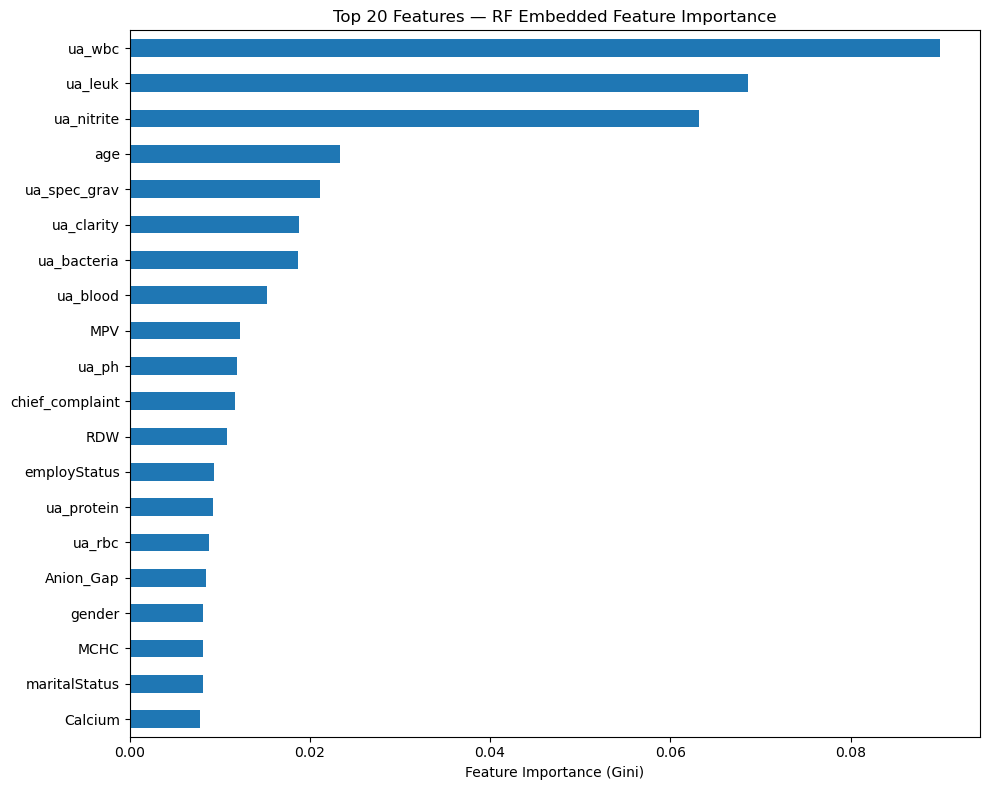

In [118]:
# Plot feature importances (top 20)
fig, ax = plt.subplots(figsize=(10, 8))
feat_importance.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Features — RF Embedded Feature Importance")
plt.tight_layout()
plt.show()

---
## Section 7: Stability For Top 20 Features

Split the training data into 5 subsamples (each 20% of training data).  
For each subsample, we run RF feature selection and get top 20 features.  
Then, we compute Jaccard Index (pairwise) and Selection Frequency.

In [119]:
def get_top_k_features(X, y, k=20, random_state=42):
    """Train RF and return top k features by importance."""
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf.fit(X, y)
    importance = pd.Series(rf.feature_importances_, index=X.columns)
    return set(importance.nlargest(k).index)

def jaccard_index(set_a, set_b):
    """Compute Jaccard Index between two sets."""
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0

In [120]:
# Create 5 stability splits (each 20% of training data)
n_splits = 5
split_size = 0.2
stability_feature_sets = []

for i in range(n_splits):
    # Sample 20% of training data
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, 
        train_size=split_size, 
        random_state=RANDOM_STATE + i,
        stratify=y_train
    )
    # Get top 20 features from this subsample
    top_feats = get_top_k_features(X_sub, y_sub, k=20, random_state=RANDOM_STATE)
    stability_feature_sets.append(top_feats)
    
    print(f"Split {i+1}: {len(X_sub)} samples, top 20 features selected")

print(f"\nTotal splits: {len(stability_feature_sets)}")

Split 1: 10289 samples, top 20 features selected
Split 2: 10289 samples, top 20 features selected
Split 3: 10289 samples, top 20 features selected
Split 4: 10289 samples, top 20 features selected
Split 5: 10289 samples, top 20 features selected

Total splits: 5


In [121]:
# Compute pairwise Jaccard Index
jaccard_scores = []
for (i, set_a), (j, set_b) in combinations(enumerate(stability_feature_sets), 2):
    ji = jaccard_index(set_a, set_b)
    jaccard_scores.append({"Split_i": i+1, "Split_j": j+1, "Jaccard_Index": ji})

jaccard_df = pd.DataFrame(jaccard_scores)
print("Pairwise Jaccard Index")
print(jaccard_df.to_string(index=False))
print(f"\nMean Jaccard Index: {jaccard_df['Jaccard_Index'].mean():.4f}")
print(f"Std Jaccard Index:  {jaccard_df['Jaccard_Index'].std():.4f}")

Pairwise Jaccard Index
 Split_i  Split_j  Jaccard_Index
       1        2       0.818182
       1        3       0.818182
       1        4       0.818182
       1        5       0.818182
       2        3       0.818182
       2        4       0.904762
       2        5       0.818182
       3        4       0.739130
       3        5       0.739130
       4        5       0.818182

Mean Jaccard Index: 0.8110
Std Jaccard Index:  0.0465


In [122]:
# Compute Selection Frequency for each feature
all_features_in_splits = [feat for feat_set in stability_feature_sets for feat in feat_set]
selection_freq = pd.Series(all_features_in_splits).value_counts() / n_splits
selection_freq = selection_freq.sort_values(ascending=False)

print("Feature Selection Frequency (across 5 splits)")
print(selection_freq.to_string())

Feature Selection Frequency (across 5 splits)
ua_bacteria        1.0
ua_spec_grav       1.0
ua_blood           1.0
MPV                1.0
MCHC               1.0
age                1.0
ua_wbc             1.0
chief_complaint    1.0
ua_protein         1.0
ua_nitrite         1.0
ua_ph              1.0
ua_clarity         1.0
RDW                1.0
ua_rbc             1.0
Anion_Gap          1.0
employStatus       1.0
ua_leuk            1.0
Potassium          0.8
Calcium            0.4
gender             0.4
maritalStatus      0.4
Monocytes          0.2
Platelets          0.2
RBC                0.2
Hemoglobin         0.2
Neutrophils        0.2


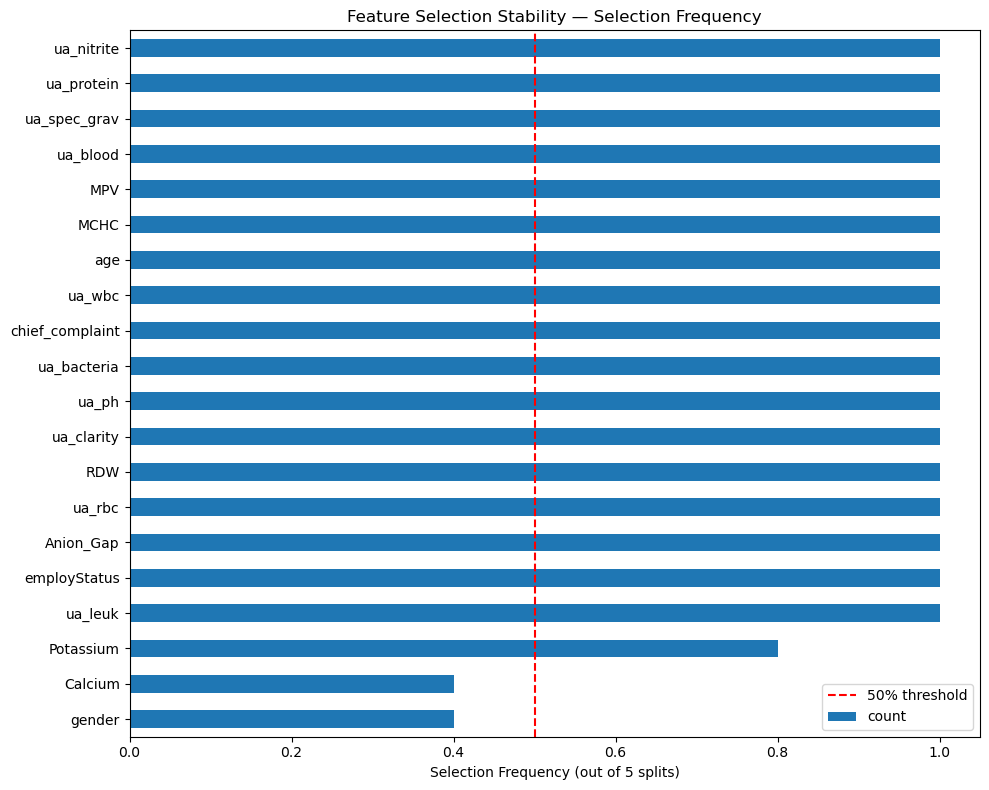

In [123]:
# Plot selection frequency
fig, ax = plt.subplots(figsize=(10, 8))
selection_freq.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel("Selection Frequency (out of 5 splits)")
ax.set_title("Feature Selection Stability — Selection Frequency")
ax.axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Short Answer 2:**  
The top 10 features identified are: ua_wbc (0.0899), ua_leuk (0.0686), ua_nitrite (0.0631),
age (0.0233), ua_spec_grav (0.0211), ua_clarity (0.0188), ua_bacteria (0.0187), ua_blood (0.0152),
MPV (0.0123), and ua_ph (0.0119).

The top 20 features identified are: ua_wbc (0.0899), ua_leuk (0.0686), ua_nitrite (0.0631),
age (0.0233), ua_spec_grav (0.0211), ua_clarity (0.0188), ua_bacteria (0.0187), ua_blood (0.0152),
MPV (0.0123), ua_ph (0.0119), chief_complaint (0.0117), RDW (0.0108), employStatus (0.0093),
ua_protein (0.0093), ua_rbc (0.0088), Anion_Gap (0.0084), gender (0.0082), MCHC (0.0081),
maritalStatus (0.0081), and Calcium (0.0078).

The stability analysis of the 20 features across 5 data splits showed overall high consistency, with a mean Jaccard Index of 0.8110 (SD = 0.0465). Among them, 17 of the 20 features, including ua_wbc, ua_leuk, ua_nitrite, age, ua_spec_grav, ua_clarity, ua_bacteria, ua_blood, MPV, ua_ph, chief_complaint, RDW, employStatus, ua_protein, ua_rbc, Anion_Gap, and MCHC, were selected in all 5 splits with a frequency of 1.0. In contrast, gender, maritalStatus, and Calcium each appeared in only 40% of the splits.


---
## Section 8: Model Training — Random Forest (10 vs 20 features)

In [124]:
print(f"Test set:       {X_test.shape[0]} samples  ({y_test.mean():.2%} positive)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean():.2%} positive)")

Test set:       12862 samples  (22.89% positive)
Validation set: 16077 samples (22.18% positive)


In [125]:
# Model 1: Top 10 features
rf_10 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_10.fit(X_train[top_10_features], y_train)
print("Model 1 (10 features) trained.")

# Model 2: Top 20 features
rf_20 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_20.fit(X_train[top_20_features], y_train)
print("Model 2 (20 features) trained.")

Model 1 (10 features) trained.
Model 2 (20 features) trained.


---
## Section 9: Model Evaluation — AUC, PR-AUC, Calibration Curve

In [126]:
def evaluate_model(model, X_eval, y_eval, features, dataset_name, model_name):
    """
    Evaluate a model and return metrics.
    Returns dict with AUC-ROC, PR-AUC, and data for plotting.
    """
    y_prob = model.predict_proba(X_eval[features])[:, 1]
    
    # AUC-ROC
    auc_roc = roc_auc_score(y_eval, y_prob)
    fpr, tpr, _ = roc_curve(y_eval, y_prob)
    
    # PR-AUC
    pr_auc = average_precision_score(y_eval, y_prob)
    precision, recall, _ = precision_recall_curve(y_eval, y_prob)
    
    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_eval, y_prob, n_bins=10)
    
    print(f"{model_name} on {dataset_name}: AUC-ROC={auc_roc:.4f}, PR-AUC={pr_auc:.4f}")
    
    return {
        "model_name": model_name,
        "dataset": dataset_name,
        "auc_roc": auc_roc,
        "pr_auc": pr_auc,
        "fpr": fpr, "tpr": tpr,
        "precision": precision, "recall": recall,
        "prob_true": prob_true, "prob_pred": prob_pred
    }

In [127]:
# Evaluate both models on test and validation sets
results = []

results.append(evaluate_model(rf_10, X_test, y_test, top_10_features, "Test", "RF-10"))
results.append(evaluate_model(rf_10, X_val, y_val, top_10_features, "Validation", "RF-10"))
results.append(evaluate_model(rf_20, X_test, y_test, top_20_features, "Test", "RF-20"))
results.append(evaluate_model(rf_20, X_val, y_val, top_20_features, "Validation", "RF-20"))

RF-10 on Test: AUC-ROC=0.8459, PR-AUC=0.6885
RF-10 on Validation: AUC-ROC=0.8526, PR-AUC=0.6826
RF-20 on Test: AUC-ROC=0.8733, PR-AUC=0.7326
RF-20 on Validation: AUC-ROC=0.8791, PR-AUC=0.7259


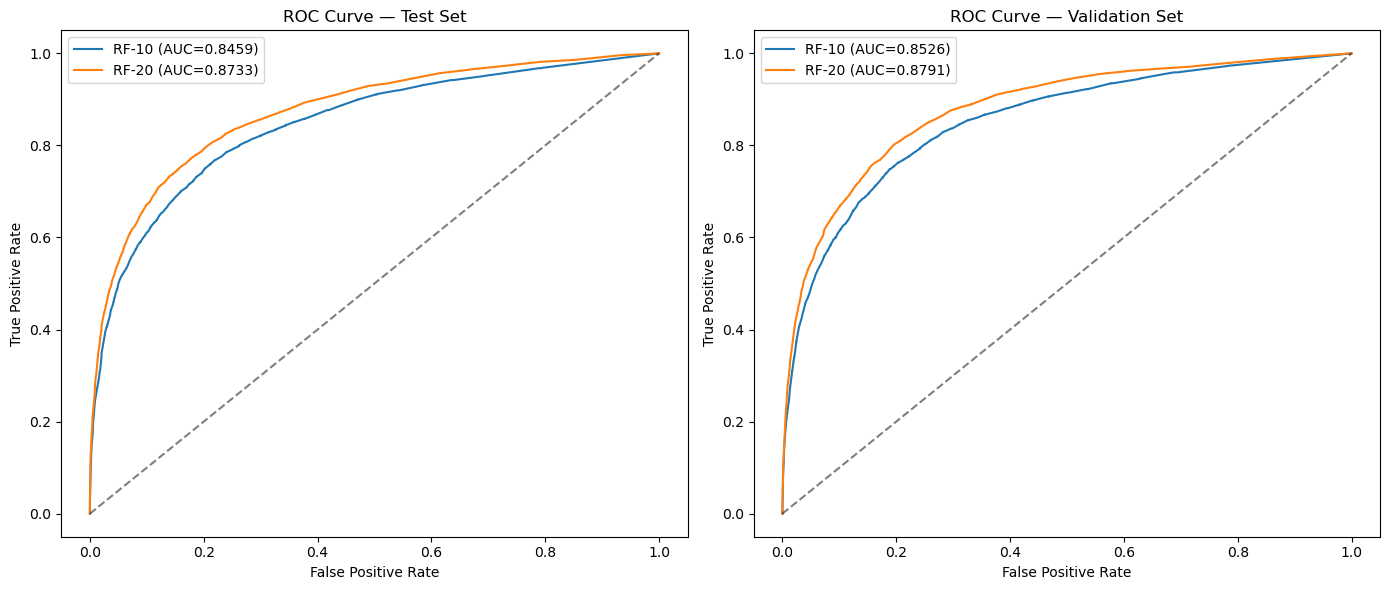

In [128]:
# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for dataset_name, ax in zip(["Test", "Validation"], axes):
    for r in results:
        if r["dataset"] == dataset_name:
            ax.plot(r["fpr"], r["tpr"], 
                    label=f"{r['model_name']} (AUC={r['auc_roc']:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {dataset_name} Set")
    ax.legend()

plt.tight_layout()
plt.show()

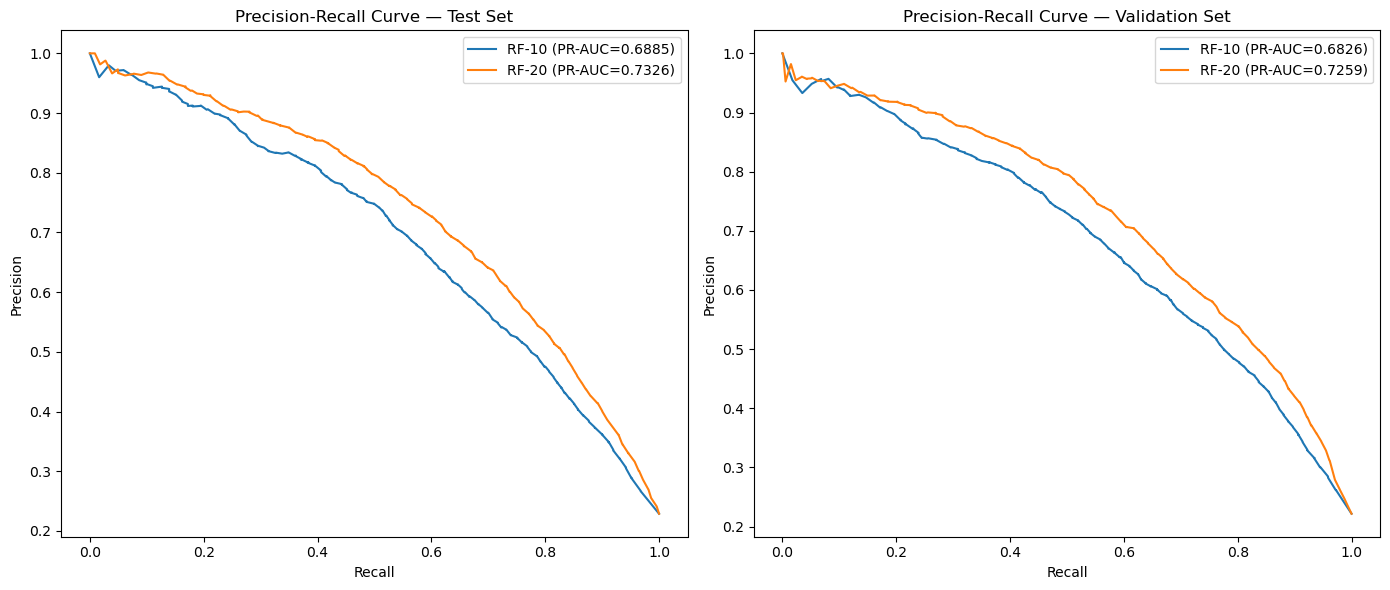

In [129]:
# Plot PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for dataset_name, ax in zip(["Test", "Validation"], axes):
    for r in results:
        if r["dataset"] == dataset_name:
            ax.plot(r["recall"], r["precision"], 
                    label=f"{r['model_name']} (PR-AUC={r['pr_auc']:.4f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve — {dataset_name} Set")
    ax.legend()

plt.tight_layout()
plt.show()

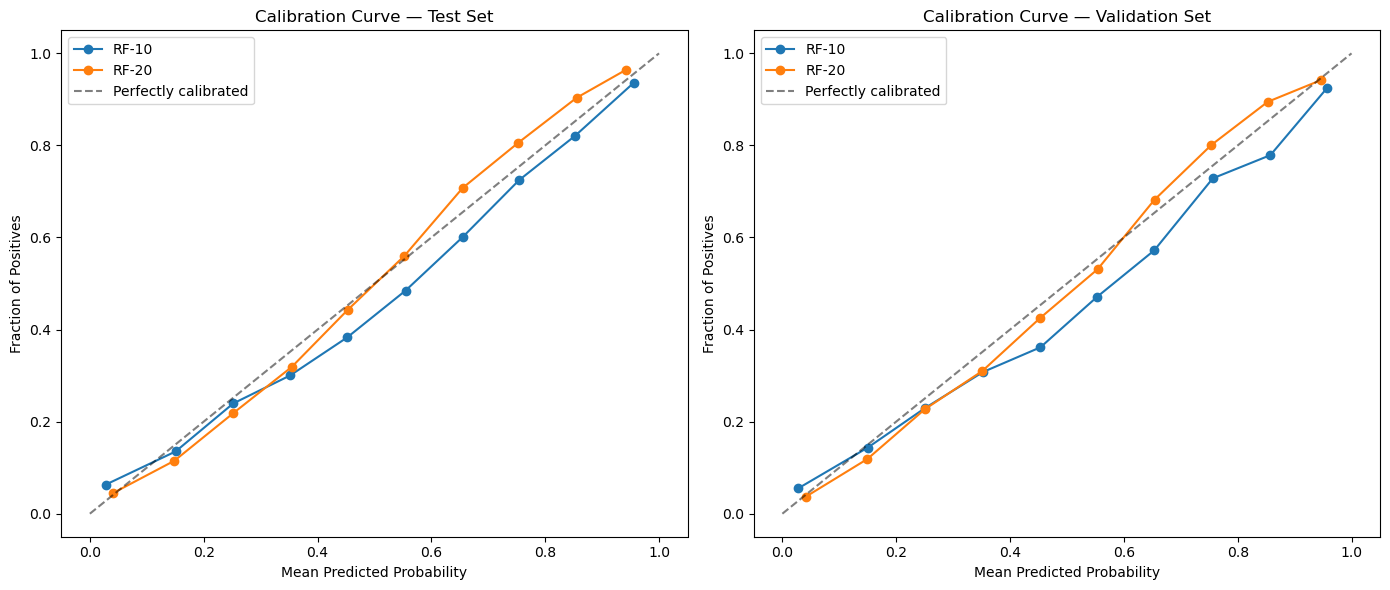

In [130]:
# Plot Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for dataset_name, ax in zip(["Test", "Validation"], axes):
    for r in results:
        if r["dataset"] == dataset_name:
            ax.plot(r["prob_pred"], r["prob_true"], 
                    marker='o', label=r["model_name"])
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"Calibration Curve — {dataset_name} Set")
    ax.legend()

plt.tight_layout()
plt.show()

### For Extra Point

RF-10 | Test | Sens=0.769 | Spec=0.780 | PPV=0.509 | NPV=0.919
RF-10 | Validation | Sens=0.748 | Spec=0.812 | PPV=0.531 | NPV=0.919
RF-20 | Test | Sens=0.754 | Spec=0.840 | PPV=0.584 | NPV=0.920
RF-20 | Validation | Sens=0.802 | Spec=0.804 | PPV=0.538 | NPV=0.934


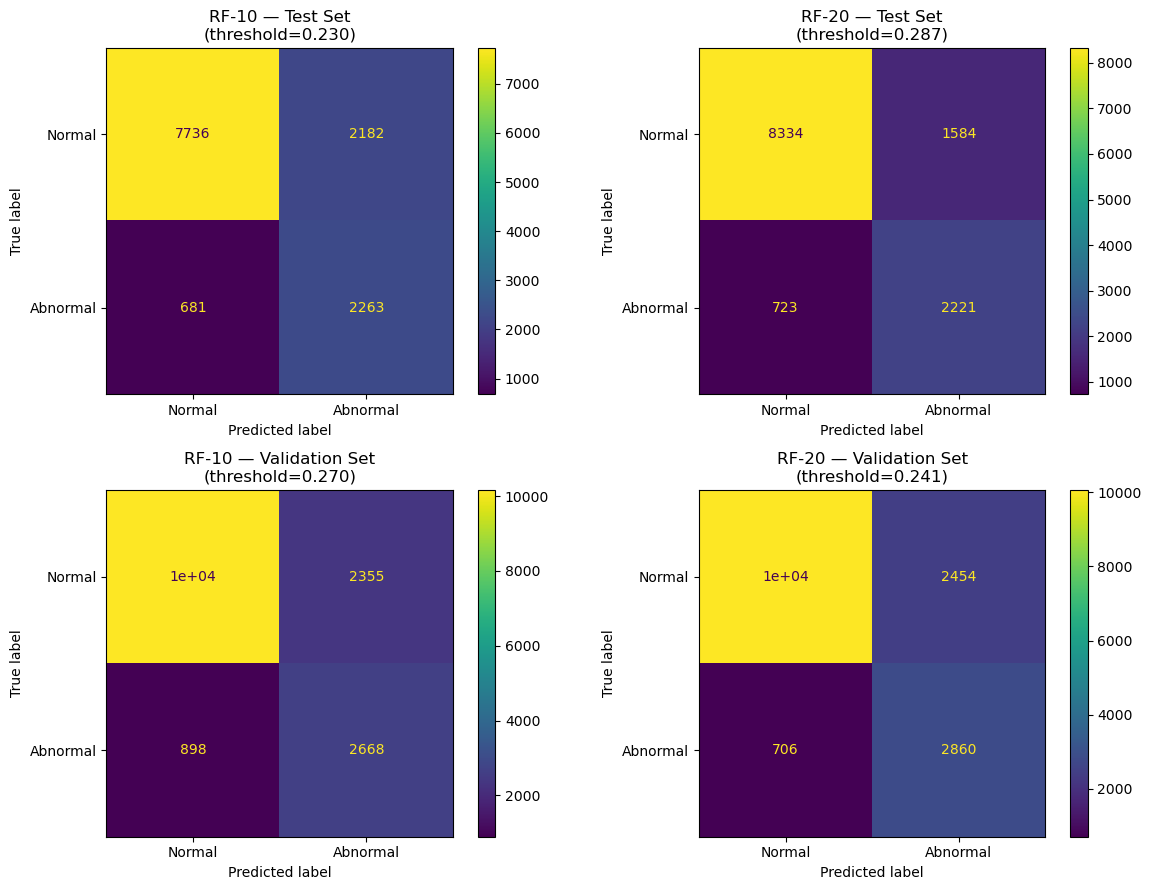

In [131]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay,confusion_matrix
models = [
    ("RF-10", rf_10, top_10_features),
    ("RF-20", rf_20, top_20_features),
]
datasets = [
    ("Test",       X_test, y_test),
    ("Validation", X_val,  y_val),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, (model_name, model, feats) in enumerate(models):
    for row, (dataset_name, X_eval, y_eval) in enumerate(datasets):
        y_prob = model.predict_proba(X_eval[feats])[:, 1]
        fpr, tpr, thresholds = roc_curve(y_eval, y_prob)
        best_thresh = thresholds[np.argmax(tpr - fpr)]
        y_pred = (y_prob >= best_thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()
        print(f"{model_name} | {dataset_name} | "
              f"Sens={tp/(tp+fn):.3f} | Spec={tn/(tn+fp):.3f} | "
              f"PPV={tp/(tp+fp):.3f} | NPV={tn/(tn+fn):.3f}")
        ax = axes[row, col]
        ConfusionMatrixDisplay.from_predictions(
            y_eval, y_pred,
            display_labels=["Normal", "Abnormal"],
            ax=ax
        )
        ax.set_title(f"{model_name} — {dataset_name} Set\n(threshold={best_thresh:.3f})")

plt.tight_layout()
plt.show()


**Short Answer 3:**  
Our approach reduces the risk of data leakage through several strategies. First, the feature matrix X was constructed from a predefined allowlist of predictor columns (PREDICTOR_COLS), which excluded alternative labels (UTI_diag, abxUTI, alt_diag), administrative identifiers (ID, PATID), and disposition (dispo) by construction. In addition, the split column was used to get the development and validation set from the raw data before the feature matrix was created, so it never appeared as a predictor. Within the development set, an 80/20 stratified split was applied to create a training set and a held-out test set. All feature selection steps, including random forest importance ranking, were performed exclusively on the training partition.